In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense 
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split

In [3]:
X_train=np.linspace(-1,1,20)

In [4]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [5]:
X_test = np.linspace(-1, 1, 20)

In [6]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

In [7]:
import matplotlib.pyplot as plt


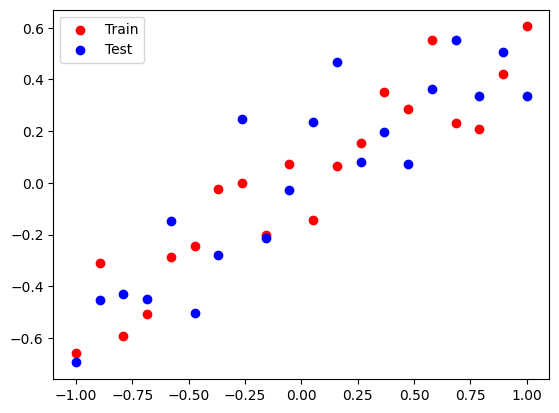

In [8]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

In [9]:
model=Sequential()

model.add(Dense(128,input_dim=1,activation="relu"))
model.add(Dense(128,activation="relu"))
model.add(Dense(1,activation="linear"))


c:\Users\sm\AppData\Local\anaconda3\envs\dnn\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:

model.compile(loss="mse",optimizer=tf.optimizers.Adam(learning_rate=0.01),metrics=["mse"])

In [12]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1171 - mse: 0.1171 - val_loss: 0.0326 - val_mse: 0.0326
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0203 - mse: 0.0203 - val_loss: 0.0517 - val_mse: 0.0517
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0397 - mse: 0.0397 - val_loss: 0.0352 - val_mse: 0.0352
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0221 - mse: 0.0221 - val_loss: 0.0341 - val_mse: 0.0341
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0210 - mse: 0.0210 - val_loss: 0.0363 - val_mse: 0.0363
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0238 - mse: 0.0238 - val_loss: 0.0357 - val_mse: 0.0357
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0234 - mse: 0.0234 - val_loss: 0.0315 - val_mse: 0.0315
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0192 - mse: 0.0192 - val_loss: 0.0296 - val_mse: 0.0296
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0169 - mse

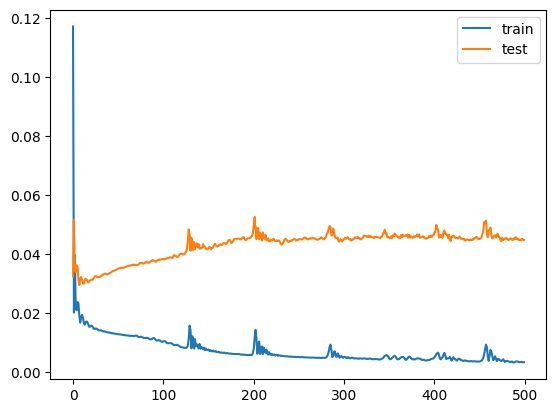

In [14]:
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="test")
plt.legend()
plt.show()

In [15]:
_,train_mse=model.evaluate(X_train,y_train)
_,test_mse=model.evaluate(X_test,y_test)
print(train_mse,test_mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0034 - mse: 0.0034
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0449 - mse: 0.0449
0.0033567617647349834 0.04489661008119583


In [16]:
y_pred_1 = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


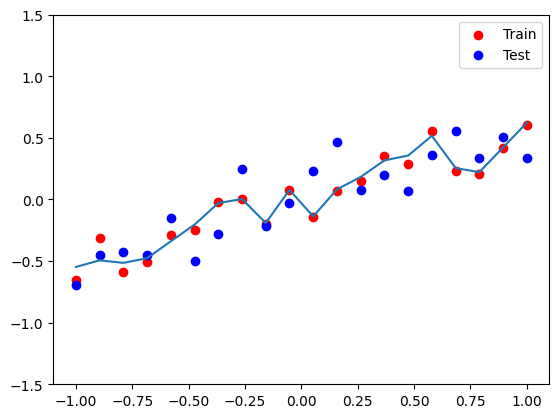

In [17]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

#### DROP OUT

In [35]:
model_1=Sequential()

model_1.add(Dense(128,input_dim=1,activation="relu"))
model_1.add(Dropout(0.5))
model_1.add(Dense(128,activation="relu"))
model_1.add(Dropout(0.5))
model_1.add(Dense(1,activation="linear"))

c:\Users\sm\AppData\Local\anaconda3\envs\dnn\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model_1.compile(loss="mse",optimizer=tf.optimizers.Adam(learning_rate=0.01),metrics=["mse"])

In [38]:
callback=tf.keras.callbacks.EarlyStopping(monitor="val_loss",min_delta=0.01,patience=10,mode="auto",restore_best_weights=False,verbose=1)

In [39]:
history=model_1.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=500,callbacks=callback)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0861 - mse: 0.0861 - val_loss: 0.0319 - val_mse: 0.0319
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.0456 - mse: 0.0456 - val_loss: 0.0575 - val_mse: 0.0575
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.0836 - mse: 0.0836 - val_loss: 0.0419 - val_mse: 0.0419
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0516 - mse: 0.0516 - val_loss: 0.0288 - val_mse: 0.0288
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0350 - mse: 0.0350 - val_loss: 0.0398 - val_mse: 0.0398
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.0544 - mse: 0.0544 - val_loss: 0.0503 - val_mse: 0.0503
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0283 - mse: 0.0283 - val_loss: 0.0515 - val_mse: 0.0515
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0429 - mse: 0.0429 - val_loss: 0.0451 - val_mse: 0.0451
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0519 -

In [40]:
_,train_mse=model_1.evaluate(X_train,y_train)
_,test_mse=model_1.evaluate(X_test,y_test)
print(train_mse,test_mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0177 - mse: 0.0177
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0296 - mse: 0.0296
0.017732413485646248 0.029551338404417038


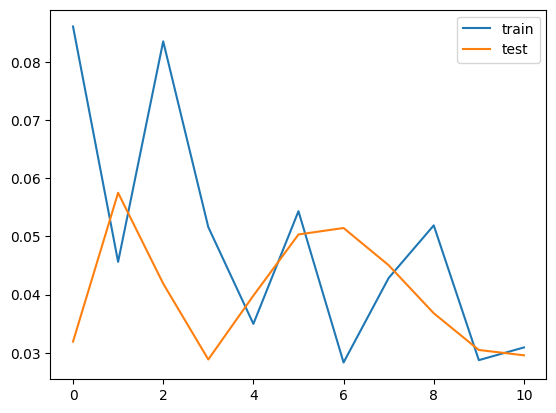

In [41]:
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="test")
plt.legend()
plt.show()